In [8]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

In [2]:
if Path.cwd().name == "notebooks":
    os.chdir("..")
print(Path.cwd())

/Users/majdalsuleh/Projects/mining-quality-prediction


In [3]:
df = pd.read_csv("data/model_table.csv", index_col="hour", parse_dates=True)

train = df[df.index < "2017-07-01"]
val   = df[(df.index >= "2017-07-01") & (df.index < "2017-08-01")]
test  = df[df.index >= "2017-08-01"]

print(len(train), "train |", len(val), "validation |", len(test), "test")

1979 train | 692 validation | 814 test


In [4]:
def score(name, y_true, y_pred):
    return {
        "model": name,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 3),
        "RMSE": round(root_mean_squared_error(y_true, y_pred), 3),
    }

In [5]:
results = [
    score("Always predict the average", val["target"],
          np.full(len(val), train["target"].mean())),
    score("Same as last known (silica_now)", val["target"], val["silica_now"]),
]
pd.DataFrame(results)

,model,MAE,RMSE
0,Always predict the average,0.872,1.038
1,Same as last known (silica_now),0.506,0.825


In [9]:
X_cols = [c for c in df.columns if c != "target"]
print(len(X_cols), "features")

50 features


In [10]:
ridge = make_pipeline(StandardScaler(), Ridge(alpha=10))
ridge.fit(train[X_cols], train["target"])

results.append(score("Ridge", val["target"], ridge.predict(val[X_cols])))

In [11]:
xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
)
xgb.fit(train[X_cols], train["target"])

results.append(score("XGBoost", val["target"], xgb.predict(val[X_cols])))

In [12]:
pd.DataFrame(results)

,model,MAE,RMSE
0,Always predict the average,0.872,1.038
1,Same as last known (silica_now),0.506,0.825
2,Ridge,0.530,0.767
3,XGBoost,0.572,0.780


In [13]:
y_change = train["target"] - train["silica_now"]

ridge_chg = make_pipeline(StandardScaler(), Ridge(alpha=100))
ridge_chg.fit(train[X_cols], y_change)
pred = val["silica_now"] + ridge_chg.predict(val[X_cols])
results.append(score("Ridge (change)", val["target"], pred))

xgb_chg = XGBRegressor(
    n_estimators=300, learning_rate=0.03, max_depth=3,
    subsample=0.8, colsample_bytree=0.8,
    objective="reg:absoluteerror", random_state=42,
)
xgb_chg.fit(train[X_cols], y_change)
pred = val["silica_now"] + xgb_chg.predict(val[X_cols])
results.append(score("XGBoost (change)", val["target"], pred))

pd.DataFrame(results)

,model,MAE,RMSE
0,Always predict the average,0.872,1.038
1,Same as last known (silica_now),0.506,0.825
2,Ridge,0.530,0.767
3,XGBoost,0.572,0.780
4,Ridge (change),0.521,0.760
5,XGBoost (change),0.492,0.751


In [14]:
train_full = pd.concat([train, val])
y_full = train_full["target"] - train_full["silica_now"]

final_model = XGBRegressor(
    n_estimators=300, learning_rate=0.03, max_depth=3,
    subsample=0.8, colsample_bytree=0.8,
    objective="reg:absoluteerror", random_state=42,
)
final_model.fit(train_full[X_cols], y_full)
test_pred = test["silica_now"] + final_model.predict(test[X_cols])

test_results = pd.DataFrame([
    score("Always predict the average", test["target"],
          np.full(len(test), train_full["target"].mean())),
    score("Same as last known", test["target"], test["silica_now"]),
    score("XGBoost (change)", test["target"], test_pred),
])
test_results

,model,MAE,RMSE
0,Always predict the average,0.910,1.143
1,Same as last known,0.488,0.752
2,XGBoost (change),0.521,0.726


In [15]:
change = (test["target"] - test["silica_now"]).abs()
bins = pd.cut(change, [0, 0.25, 1, 10], right=False,
              labels=["calm (<0.25)", "medium (0.25–1)", "big jump (>1)"])

pd.DataFrame({
    "hours": change.groupby(bins).size(),
    "baseline_MAE": (test["target"] - test["silica_now"]).abs().groupby(bins).mean().round(2),
    "model_MAE": (test["target"] - test_pred).abs().groupby(bins).mean().round(2),
})

,hours,baseline_MAE,model_MAE
calm (<0.25),379,0.11,0.26
medium (0.25–1),325,0.53,0.51
big jump (>1),110,1.66,1.44


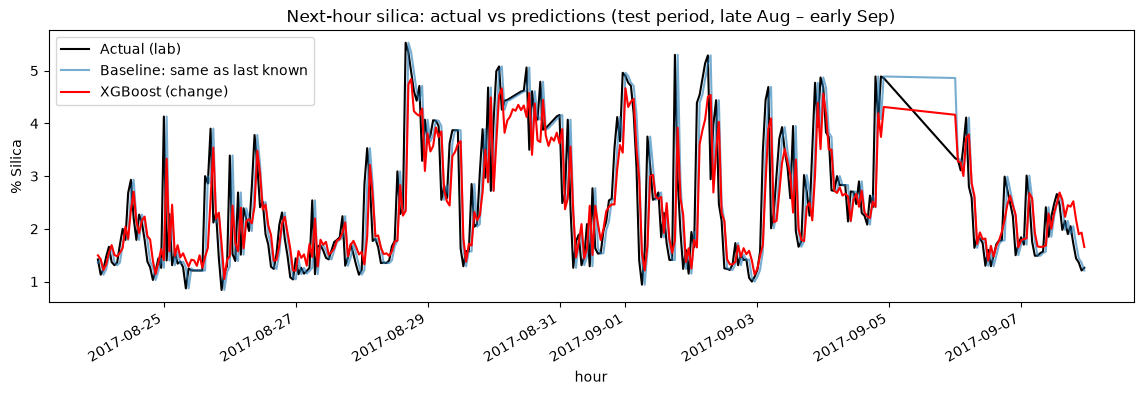

In [17]:
window = slice("2017-08-24", "2017-09-07")

fig, ax = plt.subplots(figsize=(14, 4))
test.loc[window, "target"].plot(ax=ax, color="black", label="Actual (lab)")
test.loc[window, "silica_now"].plot(ax=ax, alpha=0.6, label="Baseline: same as last known")
pd.Series(test_pred, index=test.index).loc[window].plot(ax=ax, color="red", label="XGBoost (change)")

ax.set_ylabel("% Silica")
ax.set_title("Next-hour silica: actual vs predictions (test period, late Aug – early Sep)")
ax.legend()
plt.savefig("reports/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

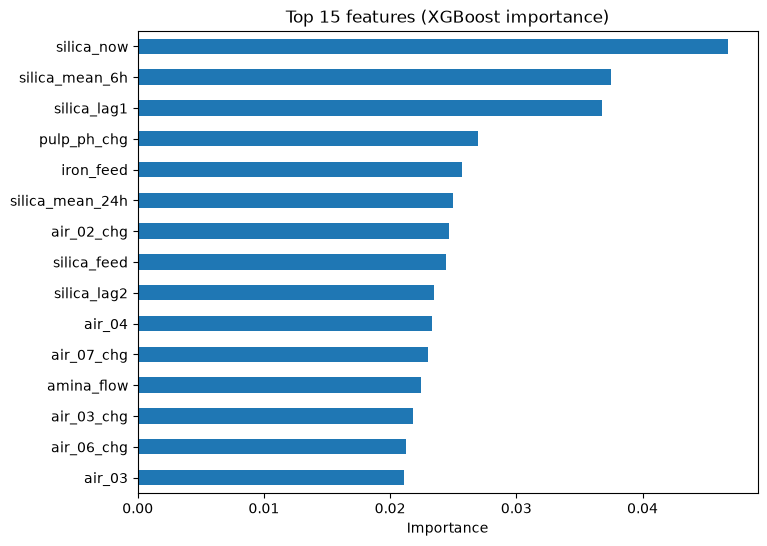

In [18]:
importance = (
    pd.Series(final_model.feature_importances_, index=X_cols)
    .sort_values()
    .tail(15)
)

ax = importance.plot.barh(figsize=(8, 6))
ax.set_title("Top 15 features (XGBoost importance)")
ax.set_xlabel("Importance")
plt.savefig("reports/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()